# Habit Formation with Portfolio Choice

The [habit formation model](./HabitConsumerType.ipynb) extends the workhorse consumption-saving model to include consumption habits, where agents get utility from the ratio of consumption to a habit stock. The [portfolio choice model](../ConsPortfolioModel/RiskyAssetConsumerType.ipynb) extends the same baseline model to allow agents to allocate their wealth between a risk-free and a risky asset.

This notebook develops the mathematical framework for a model that combines **both** extensions: agents have consumption habits *and* can choose their portfolio allocation. This is a natural combination: an agent whose utility depends on maintaining consumption relative to a habit stock will have different attitudes toward portfolio risk than an agent with standard preferences.

We derive the model statement, end-of-period value functions, first order conditions, and the solution algorithm, following the style established in the habit formation notebook.

In [1]:
import matplotlib.pyplot as plt
from HARK.models import HabitPortfolioConsumerType
from HARK.utilities import plot_func_slices
from time import time

mystr = lambda x: "{:.4f}".format(x)

$\newcommand{\CRRA}{\rho}$
$\newcommand{\LivPrb}{\mathsf{S}}$
$\newcommand{\PermGroFac}{\Gamma}$
$\newcommand{\Rfree}{\mathsf{R}}$
$\newcommand{\Risky}{\mathfrak{R}}$
$\newcommand{\DiscFac}{\beta}$
$\newcommand{\HabitWgt}{\alpha}$
$\newcommand{\HabitRte}{\lambda}$


## Model Statement

The habit-portfolio consumer faces the following problem:

\begin{align*}
\text{v}_t(m_t,h_t) &= \max_{c_t, s_t} u(c_t,h_t) + \DiscFac \LivPrb_t
\mathbb{E}_{t} \left[ (\PermGroFac_{t+1} \psi_{t+1})^{(1-\HabitWgt)(1-\CRRA)}
\text{v}_{t+1}(m_{t+1}, h_{t+1}) \right] \\
& \text{s.t.}  \\
w_t &= m_t - c_t, \\
H_t &= \HabitRte c_t + (1-\HabitRte) h_t, \\
w_t &\geq 0, \\
s_t &\in [0,1], \\
a_t &= R_t w_t, \\
R_{t} &= s_t \Risky_{t} + (1-s_t) \Rfree_{t}, \\
m_{t+1} &= a_t / (\PermGroFac_{t+1} \psi_{t+1}) + \theta_{t+1}, \\
h_{t+1} &= H_t / (\PermGroFac_{t+1} \psi_{t+1}), \\
(\psi_{t+1}, \theta_{t+1}) &\sim F_{t+1}, \\
\Risky_{t} & \sim G, \\
u(c,h) &= \frac{(c/h^\HabitWgt)^{1-\CRRA}}{1-\CRRA}.
\end{align*}

Compared to the habit-only model, there are three key differences:

1. The agent has a **second control** $s_t \in [0,1]$, the share of retained assets allocated to the risky asset. The portfolio return $R_{t+1}$ is the weighted average of risky and risk-free returns.

2. As in the portfolio choice model, **borrowing is not allowed**: the artificial borrowing constraint is hardwired at $w_t \geq 0$. Allowing an agent to borrow while holding an asset with unbounded negative returns is economically problematic.

3. The model timing is adjusted slightly so that asset returns realize within period $t$, rather than at the start of period $t+1$.

The model nests several special cases:
- $\HabitWgt \to 0$: reduces to `RiskyAssetConsumerType` (portfolio choice, no habits)
- $\HabitRte = 0$: habits are "frozen" and don't evolve; effectively a portfolio choice model with modified risk aversion
- $s_t$ fixed at $0$: reduces to `HabitConsumerType` (habits, no portfolio choice)
- $\HabitWgt \to 0$ and $s_t$ fixed at $0$: reduces to `IndShockConsumerType`

## Solving the Habit-Portfolio Model

The key insight from the portfolio choice model is that although $c_t$ and $s_t$ are chosen simultaneously, the problem is more easily solved by imagining them to be made **sequentially**. First, the agent chooses how much to consume $c_t$ (and hence how much to save $a_t$), and *then* they choose how to split that wealth between the risky and risk-free asset with $s_t$.

When solving by backward induction, HARK thus solves the portfolio allocation problem *first*. Fixing a grid of end-of-period states, the solver finds the $s_t$ that maximizes expected value at each gridpoint. Optimal consumption $c_t$ associated with each end-of-period state can then be found using the extended EGM approach from the habit model.

The state space at decision time is $(m_t, h_t)$, exactly as in the habit-only model. With the sequential approach, the agents choose and consume $c_t$, (conceptually) advancing to the "mid-period". The mid-period state space from which the risky asset share is chosen is $(w_t, H_t)$.

### End-of-period (marginal) value

We define the end-of-period value function over retained assets $a_t$ and post-consumption habit stock $H_t$:

\begin{align*}
\mathfrak{v}_t(a_t, H_t) &= \DiscFac \LivPrb_t \mathbb{E}_{t} \left[ (\PermGroFac_{t+1} \psi_{t+1})^{(1-\HabitWgt)(1-\CRRA)} \text{v}_{t+1}(m_{t+1}, h_{t+1}) \right] \\
&\text{s.t.} \\
m_{t+1} &= a_t (\PermGroFac_{t+1} \psi_{t+1}) + \theta_{t+1}, \\
h_{t+1} &= H_t / (\PermGroFac_{t+1} \psi_{t+1}), \\
(\psi_{t+1},\theta_{t+1}) &\sim F_{t+1}. \\
\end{align*}

Because of the adjustment in model timing, the asset returns from the portfolio chosen in period $t$ *have already occured*, so the end-of-period value function only integrates over period $t+1$ income shocks.

The marginal values with respect to each end-of-period state are:

\begin{align*}
\mathfrak{v}_t^a(a_t,H_t) &= \DiscFac \LivPrb_t \mathbb{E}_{F} \left[ (\PermGroFac_{t+1} \psi_{t+1})^{\HabitWgt\CRRA-\HabitWgt-\CRRA} \text{v}_{t+1}^m(m_{t+1}, h_{t+1}) \right], \\
\mathfrak{v}_t^H(a_t,H_t) &= \DiscFac \LivPrb_t  \mathbb{E}_{F} \left[ (\PermGroFac_{t+1} \psi_{t+1})^{\HabitWgt\CRRA-\HabitWgt-\CRRA} \text{v}_{t+1}^h(m_{t+1}, h_{t+1}) \right].
\end{align*}

The first two expressions parallel the habit-only model, except for the absence of the asset return factor in the marginal value of end-of-period assets. It is thus equivalent to the math from the basic habit formation model, but with $\Rfree_t = 1$.

### Solving for optimal risky share and mid-period value

From the perspective of the mid-period, when the agent has (conceptually) already consumed, their portfolio allocation problem is:

\begin{align*}
\overline{v}_t(w_t,H_t) &= \max_{s_t} \mathbb{E}_{G} \left[ \mathfrak{v}_t(a_t, H_t) \right] \\
&\text{s.t.} \\
s_t &\in [0,1], \\
a_t &= R_t w_t, \\
R_{t} &= s_t \Risky_{t} + (1-s_t) \Rfree_{t}, \\
\Risky_{t} & \sim G.
\end{align*}

Or, substituting in the constraints, simply:

\begin{equation*}
\overline{v}_t(w_t,H_t) = \max_{s_t \in [0,1]} \mathbb{E}_{G} \left[ \mathfrak{v}_t((s_t \Risky_{t} + (1-s_t) \Rfree_{t}) w_t, H_t) \right] ~~ \text{s.t.} ~~ \Risky_{t} \sim G.
\end{equation*}

The portfolio allocation problem has a single first order condition for optimal (interior) risky asset share:

\begin{equation*}
\mathbb{E}_{G} \left[ w_t (\Risky_{t} - \Rfree_{t})\, \mathfrak{v}_t^a(w_t R_{t}, H_t) \right] = 0.
\end{equation*}

This FOC can be numerically solved on a grid of $(w_t, H_t)$ mid-period state space points using methods effectively identical to those for the basic `RiskyAssetConsumerType` (see [here](../ConsPortfolioModel/RiskyAssetConsumerType.ipynb)). While there is a second state dimension in this model, it has **no dynamics** within the portfolio-allocation problem. A risky share function can be constructed using ordinary interpolation methods.

Once the optimal risky share $s_t$ has been found for each $(w_t, H_t)$ on the grid, the mid-period marginal value of wealth $w_t$ and post-consumption habit stock $H_t$ can be calculated as:

\begin{align*}
\overline{v}_t^w(w_t,H_t) &= \mathbb{E}_{G} \left[ R_t \mathfrak{v}_t^a( R_t w_t, H_t) \right], \\
\overline{v}_t^H(w_t,H_t) &= \mathbb{E}_{G} \left[ \mathfrak{v}_t^H( R_t w_t, H_t) \right].
\end{align*}

These marginal value functions will be used as the continuation functions in the consumption stage of the problem.

### Solving for optimal consumption

Rolling back a step within period $t$, we now consider the agent who has just received their labor income and has an idiosyncratic state characterized by $(m_t, h_t)$. We imagine that the agent *plans* to allocate their portfolio according to the optimal rule constructed above, whatever levels of $(w_t, H_t)$ they attain after consumption.

The problem in the consumption-saving step of the model is thus:

\begin{align*}
\text{v}_t(m_t,h_t) &= \max_{c_t} u(c_t,h_t) + \overline{v}_t(w_t, H_t) \\
& \text{s.t.}  \\
w_t &= m_t - c_t, \\
H_t &= \HabitRte c_t + (1-\HabitRte) h_t, \\
w_t &\geq 0.
\end{align*}

Other than a change of symbols (i.e. the continuation value function is now $\overline{v}_t(\cdot)$ rather than $\mathfrak{v}_t(\cdot)$, and market resources not consumed are labeled $w_t$ rather than $a_t$), this problem is **exactly identical** to that faced by a consumer in the basic habit-formation model. Future risk in the form of risky asset returns $\Risky_t$ and income shocks ($\psi_{t+1}$ and $\theta_{t+1}$) have already been integrated out and incorporated into the mid-period value function.

The first order condition for optimal consumption thus takes an identical form:

\begin{equation*}
u^c(c_t,h_t) - \overline{v}_t^w(w_t,H_t) + \HabitRte \overline{v}_t^H(w_t,H_t) = 0.
\end{equation*}

The solution method for the consumption-saving step proceeds identically to the base habit-formation model, including the construction of marginal value functions $\text{v}^m_t(\cdot)$ and $\text{v}^h_t(\cdot)$ via the envelope conditions. To avoid repetition, please see the complete presentation in [that notebook](HabitConsumerType.ipynb).

## Example Parameters

The parameters for a `HabitPortfolioConsumerType` combine those from both parent models. The table below presents the full set:

| Parameter | Description | Code | Example value | Time-varying? |
| :---: | --- | --- | --- | --- |
| $\DiscFac$ |Intertemporal discount factor  | `DiscFac` | $0.96$ |  |
| $\CRRA$ |Coefficient of relative risk aversion | `CRRA` | $2.0$ | |
| $\HabitWgt$ | Weight on habit stock in utility function | `HabitWgt` | $0.5$ | |
| $\HabitRte$ | Rate of habit stock updating | `HabitRte` | $0.2$ | |
| $\Rfree_t$ | Risk free interest factor | `Rfree` | $[1.03]$ | $\surd$ |
| $\mu_\Risky$ | Mean risky asset return | `RiskyAvg` | $1.08$ | |
| $\sigma_\Risky$ | Std dev of log risky asset return | `RiskyStd` | $0.18$ | |
| $N_\Risky$ | Risky return distribution nodes | `RiskyCount` | $5$ | |
| $\LivPrb_t$ |Survival probability | `LivPrb` | $[0.98]$ | $\surd$ |
| $\PermGroFac_{t}$ |Permanent income growth factor| `PermGroFac` | $[1.01]$ | $\surd$ |
| $\sigma_\psi$| Std dev of log permanent income shocks | `PermShkStd` | $[0.1]$ |$\surd$ |
| $N_\psi$| Number of discrete permanent income shocks | `PermShkCount` | $7$ | |
| $\sigma_\theta$| Std dev of log transitory income shocks | `TranShkStd` | $[0.1]$ | $\surd$ |
| $N_\theta$| Number of discrete transitory income shocks | `TranShkCount` | $7$ |  |
| $\mho$ | Unemployment probability | `UnempPrb` | $0.05$ |  |
| $\underline{\theta}$| Transitory shock when unemployed | `IncUnemp` | $0.3$ |  |
| $(none)$ | Minimum value in assets grid | `aXtraMin` | $0.001$ | |
| $(none)$ | Maximum value in assets grid | `aXtraMax` | $30.0$ | |
| $(none)$ | Number of points in assets grid | `aXtraCount` | $72$ | |
| $(none)$ | Exponential nesting factor for base assets-above-minimum grid | `aXtraNestFac` | $3$ | |
| $(none)$ | Additional values to add to assets-above-minimum grid | `aXtraExtra` | $None$ | |
| $(none)$ | Minimum value in habit stock grid | `HabitMin` | $0.2$ | |
| $(none)$ | Maximum value in habit stock grid | `HabitMax` | $5.0$ | |
| $(none)$ | Number of points in habit stock grid | `HabitCount` | $41$ | |
| $(none)$ | Exponential order of habit stock grid | `HabitOrder` | $1.5$ | |
| $(none)$ | Maximum value in transformed marginal value grid | `ChiMax` | $50.0$ | |
| $(none)$ | Number of points in transformed marginal value grid | `ChiCount` | $251$ | |
| $(none)$ | Exponential order of transformed marginal value grid | `ChiOrder` | $1.5$ | |
| $K$ | Number of discrete points in risky share grid | `ShareCount` | $26$ | |

## Economic Predictions

Note that the intermediate marginal value function $\overline{v}^w(w_t, H_t)$ depends on the post-consumption habit stock $H_t$. This means that the optimal risky share $s_t$ will generally depend on $H_t$ as well.

Intuitively, an agent with a high habit stock (relative to their resources) is in a "vulnerable" position: they are accustomed to high consumption and would suffer large utility losses from a consumption drop. Such an agent should be **more conservative** in their portfolio allocation, choosing a lower risky share to reduce the chance of a bad return that would force a painful consumption cut.

Conversely, an agent with a low habit stock (or equivalently, high resources relative to habits) is in a comfortable position and can afford to take on more portfolio risk.

This interaction between habits and portfolio choice is one of the most economically interesting features of the combined model. It generates a **state-dependent risk tolerance** that varies with the agent's consumption history, not just their wealth.

The habit-portfolio model makes several testable predictions that distinguish it from either parent model:

**1. State-dependent portfolio allocation.** Unlike the standard portfolio model (where the risky share depends only on $m_t$), the optimal risky share now depends on the habit stock $h_t$ as well. Agents whose consumption has recently been high (high $h_t$) should hold more conservative portfolios.

**2. Gradual portfolio adjustment after shocks.** After a wealth shock, the habit-portfolio agent adjusts their portfolio *gradually* as their habit stock evolves. This contrasts with the standard portfolio model, where the agent immediately rebalances to the new optimal share for their wealth level.

**3. Lower risky share on average.** Habit-forming agents are effectively more risk-averse than standard agents because portfolio losses cause pain both directly (through lower wealth) and indirectly (through the need to cut consumption relative to habits). This should lead to lower average risky asset allocation.

**4. Asymmetric response to gains and losses.** After a *positive* wealth shock, the agent's habit stock is relatively low (they haven't yet adjusted consumption upward), making them more willing to take risk. After a *negative* shock, the opposite: high habits relative to resources make them more conservative. This generates a form of time-varying risk aversion tied to recent consumption experience.

## Example Implementation

The model described above has been implemented in `HARK.ConsumptionSaving.ConsHabitModel` as `HabitPortfolioConsumerType`. Results from this model are more interesting in a life-cycle setting, which we provide and example of [here](HabitPortfolio_LifeCycleDemo.ipynb) (generated by AI). For this model notebook, we present only an infinite horizon example.

In [2]:
# Make and solve an infinite horizon HabitPortfolioConsumerType with default parameters
MyType = HabitPortfolioConsumerType(
    CRRA=5.0, Rfree=[1.01], RiskyAvg=1.04, aXtraCount=150, cycles=0
)
t0 = time()
MyType.solve()
MyType.unpack("cFunc")
MyType.unpack("ShareFunc")
t1 = time()
print(
    "Solving the infinite horizon portfolio-allocation problem with habit formation took "
    + mystr(t1 - t0)
    + " seconds."
)

Solving the infinite horizon portfolio-allocation problem with habit formation took 80.0479 seconds.


The model takes a while to solve because it is infinite horizon (and thus must converge), there are two continuous state variables, the optimal risky share can only be solved for with numeric root-finding, and we chose to use a large number of gridpoints for wealth.

We can plot slices of the policy functions as they vary with the habit stock.

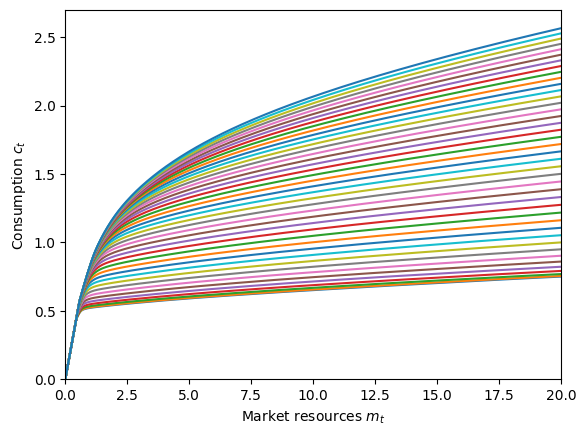

In [3]:
# Plot the consumption function
plt.ylim(0.0, 2.7)
plot_func_slices(
    MyType.cFunc[0],
    0.0,
    20.0,
    Z=MyType.HabitGrid,
    xlabel=r"Market resources $m_t$",
    ylabel=r"Consumption $c_t$",
)

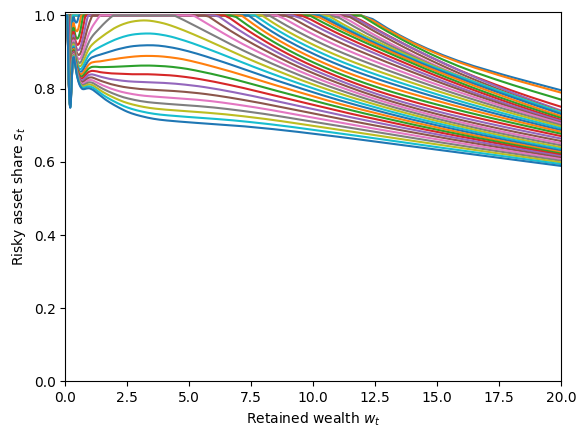

In [4]:
# Plot the risky share function
plt.ylim(0.0, 1.01)
plot_func_slices(
    MyType.ShareFunc[0],
    0.0,
    20.0,
    Z=MyType.HabitGrid,
    xlabel=r"Retained wealth $w_t$",
    ylabel=r"Risky asset share $s_t$",
)

The consumption function looks pretty normal, but the risky share function is a bit wild. It's downward sloping in wealth at *most* values of $w_t$, but is non-monotonic at low wealth. The predicted results that higher habit stock is associated with a lower risky asset share *is* consistently seen here, however.

Let's zoom in on that lower section.

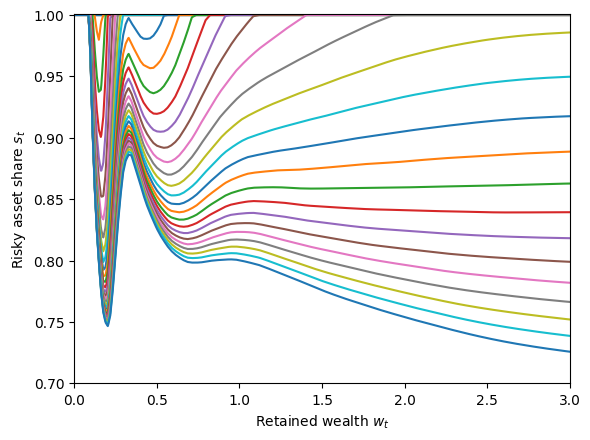

In [5]:
# Plot the risky share function at low wealth
plt.ylim(0.7, 1.001)
plot_func_slices(
    MyType.ShareFunc[0],
    0.0,
    3.0,
    Z=MyType.HabitGrid,
    xlabel=r"Retained wealth $w_t$",
    ylabel=r"Risky asset share $s_t$",
)

Trippy! But is it wrong? This is rather unexpected behavior for the risky asset share. As far as we can tell, this *is* a feature of the solution, and we aren't even the first to find it. In a model with *additive* (rather than multicative) habits, Polkovnichenko (2007) reports the same phenomenon at low wealth levels.